# Projeto 1 - Previsão de valores de veículos

## Definindo problema do negócio

* O objetivo é construir um modelo de machine learning que seja capaz de fazer previsões sobre o valor de vendas de veículos, avaliando o melhor score apresentado. A variável a ser prevista é um valor númerico que representa o valor para venda ou compra de um veículo.

* Para resolver esse problema, foi utilizado a técnica de Regressão linear

__Informações sobre as variáveis__

> Car_Name: Nome do carro  
> Year: Ano que o carro foi vendido  
> Present_Price: Preço atual decidido  
> Mks_Drivn: Total de km rodados  
> Fuel_Type: Tipo de combustivel (Diesel ou Petrol - Gasolina)  
> Seller Type: Tipo de venda  
> Transmission: Tipo de cambio (manual ou automático)  
> Owner: Dono  
> Selling_Price: O preço pelo o qual o carro foi comprado (Essa será a variável _TARGET_)  

In [1]:
import pandas as pd
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Técnicas para esquematizar o modelo preditivo
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas para calcular a taxa de erro
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# Técnicas para normalização e padronização dos dados fora de escala
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from dfply import *
from xgboost import XGBRegressor
from datetime import datetime
import joblib
import os

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
print(f'Data inicio: {str(datetime.now().strftime('%Y-%m-%d'))}')

Data inicio: 2026-03-02


In [3]:
FILE_NAME = 'cardata.csv'

if os.path.exists(FILE_NAME):
    try:
        components = np.array([os.getcwd(), FILE_NAME])
        path = os.path.join(*np.concatenate(components.reshape(-1, 1)))
    except Exception as e:
        raise NotADirectoryError(f'Folder is not a directory. Please check again!')

df = pd.read_csv(
    path,
    encoding='utf-8',
    na_filter=False,
    verbose=0,
    thousands='|',
    float_precision='legacy'
)

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Análise Exploratória (EDA)

In [4]:
df.shape

(301, 9)

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
# Verificando se há dados nulo
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
# Verificando total de valores únicos
df.nunique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

In [9]:
df.groupby(by='Fuel_Type', observed=True).size().sort_values(ascending=1)

Fuel_Type
CNG         2
Diesel     60
Petrol    239
dtype: int64

In [10]:
df.groupby(by='Seller_Type', observed=True).size().sort_values(ascending=1)

Seller_Type
Individual    106
Dealer        195
dtype: int64

In [11]:
df.groupby(by='Transmission', observed=True).size().sort_values(ascending=1)

Transmission
Automatic     40
Manual       261
dtype: int64

In [12]:
df.groupby(by='Owner', observed=True).size().sort_values(ascending=1)

Owner
3      1
1     10
0    290
dtype: int64

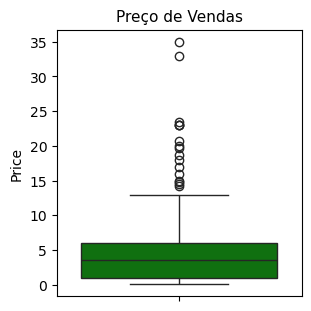

In [13]:
# Boxplot para Selling_Price

fig, ax = plt.subplots(figsize=(3, 3), layout='constrained')
sns.boxplot(df['Selling_Price'], ax=ax, color='g')

ax.set_title(f'Preço de Vendas', fontsize=11)
ax.set_ylabel(f'Price')
plt.show()

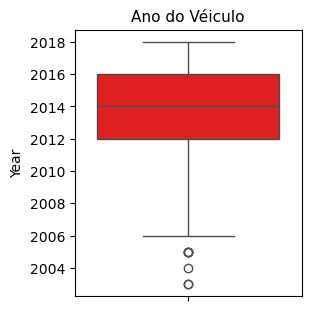

In [14]:
# Boxplot para Year

fig, ax = plt.subplots(figsize=(3, 3), layout='constrained')
sns.boxplot(df['Year'], ax=ax, color='r')

ax.set_title(f'Ano do Véiculo', fontsize=11)
plt.show()

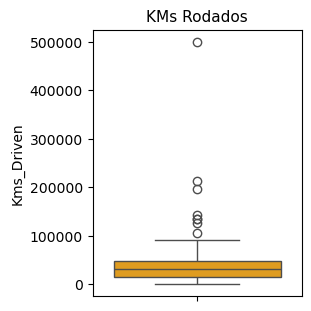

In [15]:
# Boxplot para Kms_Driven

fig, ax = plt.subplots(figsize=(3, 3), layout='constrained')
sns.boxplot(df['Kms_Driven'], ax=ax, color='orange')

ax.set_title(f'KMs Rodados', fontsize=11)
plt.show()

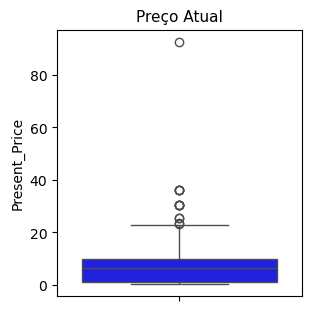

In [16]:
# Boxplot para Present_Price

fig, ax = plt.subplots(figsize=(3, 3), layout='constrained')
sns.boxplot(df['Present_Price'], ax=ax, color='blue')

ax.set_title(f'Preço Atual', fontsize=11)
plt.show()

### Tratamento de dados

In [17]:
# Obtendo a idade do carro

df['Age'] = datetime.now().year - df['Year']

In [18]:
df.drop(['Year'], axis=1, inplace=True)
df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [19]:
# Identifica e remove os outliers dos preços

df = df[df['Selling_Price'] < 33.0]

In [20]:
# Separação dos atributos preditores e target

cat_cols = [cname for cname in df.select_dtypes(include=['object']).columns.to_numpy().ravel()
           if cname != 'Car_Name']

X = df.drop(['Selling_Price', 'Car_Name'], axis=1).values
y = df['Selling_Price']
X[:10]

array([[5.59, 27000, 'Petrol', 'Dealer', 'Manual', 0, 12],
       [9.54, 43000, 'Diesel', 'Dealer', 'Manual', 0, 13],
       [9.85, 6900, 'Petrol', 'Dealer', 'Manual', 0, 9],
       [4.15, 5200, 'Petrol', 'Dealer', 'Manual', 0, 15],
       [6.87, 42450, 'Diesel', 'Dealer', 'Manual', 0, 12],
       [9.83, 2071, 'Diesel', 'Dealer', 'Manual', 0, 8],
       [8.12, 18796, 'Petrol', 'Dealer', 'Manual', 0, 11],
       [8.61, 33429, 'Diesel', 'Dealer', 'Manual', 0, 11],
       [8.89, 20273, 'Diesel', 'Dealer', 'Manual', 0, 10],
       [8.92, 42367, 'Diesel', 'Dealer', 'Manual', 0, 11]], dtype=object)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.2, 
                                                   random_state=42)

X_train.shape, X_test.shape

((239, 7), (60, 7))

In [22]:
# Transformação de variáveis categóricas -> numéricas
cat_idx = [2, 3, 4]

le = LabelEncoder()
for i in cat_idx:
    X_train[:, i] = le.fit_transform(X_train[:, i])
    X_test[:, i] = le.transform(X_test[:, i])


ct = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('impute', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), [0, 1, 2, 3, 4, 5, 6])
    ],
    remainder='passthrough'
)

In [23]:
X_train_tf = ct.fit_transform(X_train)
X_test_tf = ct.transform(X_test)

### Escolhendo o algoritmo e treinando o modelo

In [24]:
lr = LinearRegression()
lr.fit(X_train_tf, y_train)

rf = RandomForestRegressor(n_jobs=1)
rf.fit(X_train_tf, y_train)

gr = GradientBoostingRegressor()
gr.fit(X_train_tf, y_train)

xg = XGBRegressor()
xg.fit(X_train_tf, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
# Fazendo as previsões

y_pred_lr = lr.predict(X_test_tf)
y_pred_rf = rf.predict(X_test_tf)
y_pred_gr = gr.predict(X_test_tf)
y_pred_xg = xg.predict(X_test_tf)

### Avaliando a performance dos algoritmos

In [26]:
score_lr = r2_score(y_test, y_pred_lr)
score_rf = r2_score(y_test, y_pred_rf)
score_gr = r2_score(y_test, y_pred_gr)
score_xg = r2_score(y_test, y_pred_xg)

In [27]:
print(f'Score - LinearRegression -> {score_lr:.5f}')
print(f'Score - RandomForestRegressor -> {score_rf:.5f}')
print(f'Score - GradientBoostingRegressor -> {score_gr:.5f}')
print(f'Score - XGBRegressor -> {score_xg:.5f}')

Score - LinearRegression -> 0.67909
Score - RandomForestRegressor -> 0.74588
Score - GradientBoostingRegressor -> 0.89608
Score - XGBRegressor -> 0.88875


In [29]:
outcome = pd.DataFrame({
    'Models': ['LR', 'RF', 'GBR', 'XGB'],
    'R2_Score': [score_lr, score_rf, score_gr, score_xg]
})
outcome

,Models,R2_Score
0,LR,0.679088
1,RF,0.745876
2,GBR,0.896076
3,XGB,0.888747


### Salvar o modelo para deploy

In [30]:
joblib.dump(gr, 'modelo_treinado_veiculos.pk')
print('Modelo salvo com sucesso!')

Modelo salvo com sucesso!
